In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


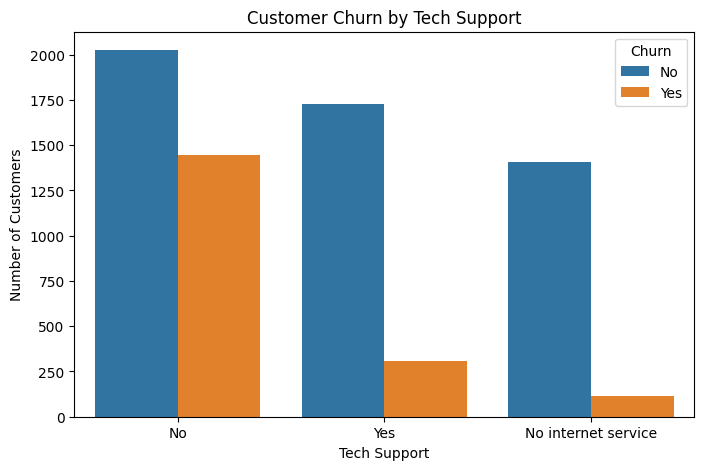

In [33]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.268482  16.731518
Credit card (automatic)    84.746877  15.253123
Electronic check           54.714588  45.285412
Mailed check               80.798005  19.201995


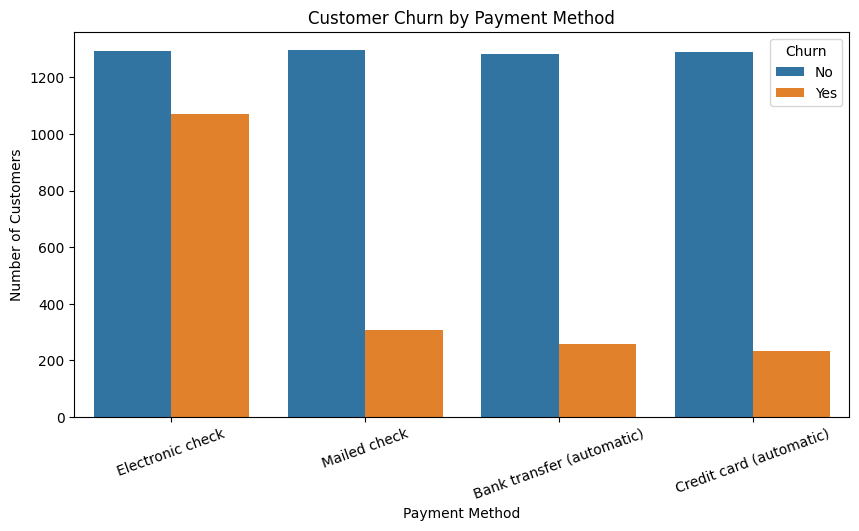

In [34]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x="PaymentMethod", hue="Churn")

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

In [35]:
df.groupby("Churn")["tenure"].agg(["mean", "median"])

,mean,median
Churn,,
No,37.650010,38.0
Yes,17.979133,10.0


In [36]:
df.groupby("Churn")["MonthlyCharges"].agg(["mean", "median"])
contract_churn
internet_churn

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


In [37]:
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


In [38]:
df.groupby("Churn")["MonthlyCharges"].agg(["mean", "median"])

,mean,median
Churn,,
No,61.307408,64.45
Yes,74.441332,79.65


In [39]:
tech_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

print(tech_churn)

Churn                       No        Yes
TechSupport                              
No                   58.352535  41.647465
No internet service  92.565789   7.434211
Yes                  84.803922  15.196078


In [40]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.268482  16.731518
Credit card (automatic)    84.746877  15.253123
Electronic check           54.714588  45.285412
Mailed check               80.798005  19.201995


In [41]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [42]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7032, 19)
Target shape: (7032,)


In [43]:
y = y.map({"No": 0, "Yes": 1})

In [44]:
print(y.value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [45]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [47]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (5625, 19)
Testing set: (1407, 19)

Training target distribution:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


In [48]:
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(5625, 19)
(1407, 19)
Churn
0    4130
1    1495
Name: count, dtype: int64
Churn
0    1033
1     374
Name: count, dtype: int64


In [49]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

In [50]:
X_train_encoded = encoder.fit_transform(
    X_train[categorical_features]
)

X_test_encoded = encoder.transform(
    X_test[categorical_features]
)

In [51]:
X_train_numeric = X_train[numerical_features].values
X_test_numeric = X_test[numerical_features].values

In [52]:
import numpy as np

X_train_processed = np.hstack([
    X_train_numeric,
    X_train_encoded
])

X_test_processed = np.hstack([
    X_test_numeric,
    X_test_encoded
])

In [53]:
print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (5625, 45)
Processed testing shape: (1407, 45)


In [54]:
encoded_feature_names = encoder.get_feature_names_out(
    categorical_features
)

feature_names = numerical_features + list(
    encoded_feature_names
)

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 45
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'PhoneService_No', 'PhoneService_Yes', 'MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_No', 'PaperlessBilling_Yes', 'PaymentMethod_Bank transfer (automatic)',

In [55]:
print(X_train_processed.shape)
print(X_test_processed.shape)
print(len(feature_names))

(5625, 45)
(1407, 45)
45


In [56]:
from imblearn.over_sampling import SMOTE

In [57]:
smote = SMOTE(
    random_state=42
)

In [58]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

In [59]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64

After SMOTE:
Churn
0    4130
1    4130
Name: count, dtype: int64


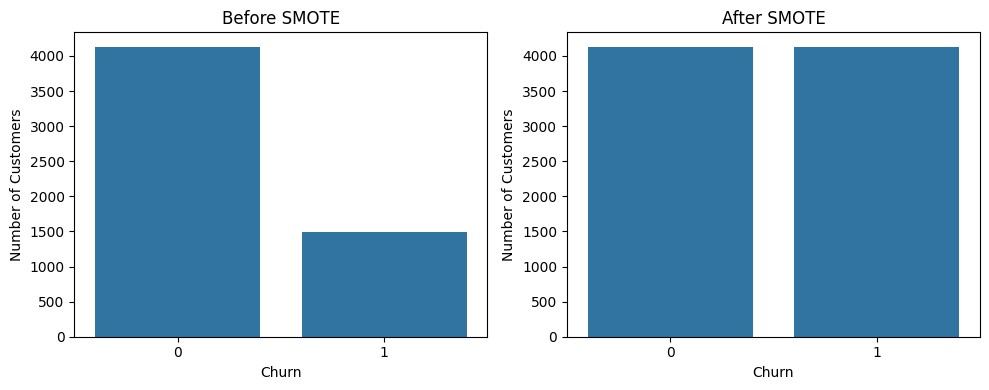

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before SMOTE
sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Number of Customers")

# After SMOTE
sns.countplot(x=y_train_smote, ax=axes[1])
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [61]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64

After SMOTE:
Churn
0    4130
1    4130
Name: count, dtype: int64


In [1]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

In [2]:
dt_model.fit(
    X_train_smote,
    y_train_smote
)

NameError: name 'X_train_smote' is not defined

In [3]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

NameError: name 'X_train_processed' is not defined

In [4]:
print(df.shape)

NameError: name 'df' is not defined

In [5]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

df = pd.read_csv(
    io.BytesIO(uploaded[list(uploaded.keys())[0]])
)

print("Dataset shape:", df.shape)

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv
Dataset shape: (7043, 21)


In [6]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

Missing TotalCharges: 11


In [7]:
df = df.dropna(subset=["TotalCharges"])

In [8]:
df = df.drop("customerID", axis=1)

print("Final cleaned shape:", df.shape)

Final cleaned shape: (7032, 20)


In [9]:
X = df.drop("Churn", axis=1)

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [10]:
print(X.shape)
print(y.value_counts())

(7032, 19)
Churn
0    5163
1    1869
Name: count, dtype: int64


In [11]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical features:", categorical_features)
print("\nNumerical features:", numerical_features)

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (5625, 19)
Testing: (1407, 19)


In [13]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_encoded = encoder.fit_transform(
    X_train[categorical_features]
)

X_test_encoded = encoder.transform(
    X_test[categorical_features]
)

In [14]:
X_train_numeric = X_train[numerical_features].values
X_test_numeric = X_test[numerical_features].values

In [15]:
import numpy as np

X_train_processed = np.hstack([
    X_train_numeric,
    X_train_encoded
])

X_test_processed = np.hstack([
    X_test_numeric,
    X_test_encoded
])

print("Training:", X_train_processed.shape)
print("Testing:", X_test_processed.shape)

Training: (5625, 45)
Testing: (1407, 45)


In [16]:
encoded_feature_names = encoder.get_feature_names_out(
    categorical_features
)

feature_names = numerical_features + list(
    encoded_feature_names
)

print("Total features:", len(feature_names))

Total features: 45


In [17]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

In [18]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nBefore SMOTE:", X_train_processed.shape)
print("After SMOTE:", X_train_smote.shape)

Before SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64

After SMOTE:
Churn
0    4130
1    4130
Name: count, dtype: int64

Before SMOTE: (5625, 45)
After SMOTE: (8260, 45)


In [19]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

In [20]:
dt_model.fit(
    X_train_smote,
    y_train_smote
)

DecisionTreeClassifier(random_state=42)

In [21]:
y_pred_dt = dt_model.predict(X_test_processed)

In [22]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7185501066098081


In [23]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

              precision    recall  f1-score   support

           0       0.82      0.79      0.80      1033
           1       0.47      0.53      0.50       374

    accuracy                           0.72      1407
   macro avg       0.65      0.66      0.65      1407
weighted avg       0.73      0.72      0.72      1407



In [24]:
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

print(cm_dt)

[[814 219]
 [177 197]]


In [25]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

NameError: name 'plt' is not defined

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

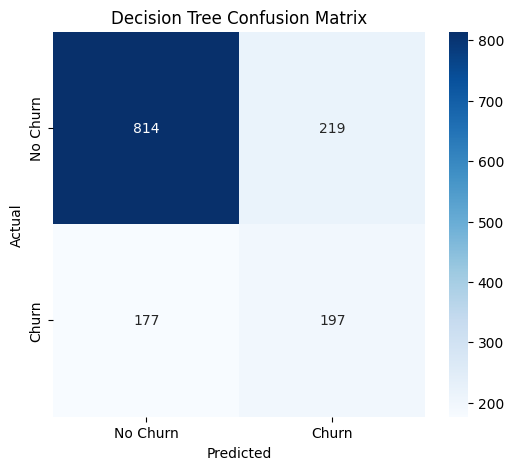

In [27]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [28]:
from sklearn.metrics import roc_auc_score

y_prob_dt = dt_model.predict_proba(
    X_test_processed
)[:, 1]

dt_auc = roc_auc_score(
    y_test,
    y_prob_dt
)

print("Decision Tree ROC-AUC:", dt_auc)

Decision Tree ROC-AUC: 0.6581914469563236


In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Decision Tree Performance")
print("-------------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_dt))

Decision Tree Performance
-------------------------
Accuracy : 0.7185501066098081
Precision: 0.4735576923076923
Recall   : 0.5267379679144385
F1 Score : 0.49873417721518987
ROC-AUC  : 0.6581914469563236


In [30]:
train_pred_dt = dt_model.predict(X_train_smote)

train_accuracy_dt = accuracy_score(
    y_train_smote,
    train_pred_dt
)

test_accuracy_dt = accuracy_score(
    y_test,
    y_pred_dt
)

print("Training Accuracy:", train_accuracy_dt)
print("Testing Accuracy :", test_accuracy_dt)

Training Accuracy: 0.9991525423728813
Testing Accuracy : 0.7185501066098081


In [31]:
from sklearn.ensemble import RandomForestClassifier

In [32]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [33]:
rf_model.fit(
    X_train_smote,
    y_train_smote
)

RandomForestClassifier(random_state=42)

In [34]:
y_pred_rf = rf_model.predict(
    X_test_processed
)

In [35]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.61      0.50      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [36]:
y_prob_rf = rf_model.predict_proba(
    X_test_processed
)[:, 1]

print("Random Forest Performance")
print("-------------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Random Forest Performance
-------------------------
Accuracy : 0.7810945273631841
Precision: 0.6071428571428571
Recall   : 0.5
F1 Score : 0.5483870967741935
ROC-AUC  : 0.8062209130770148


In [37]:
train_pred_rf = rf_model.predict(X_train_smote)

print(
    "Training Accuracy:",
    accuracy_score(y_train_smote, train_pred_rf)
)

print(
    "Testing Accuracy:",
    accuracy_score(y_test, y_pred_rf)
)

Training Accuracy: 0.9991525423728813
Testing Accuracy: 0.7810945273631841


In [38]:
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("random_forest", RandomForestClassifier(
        random_state=42
    ))
])

In [39]:
param_grid = {
    "random_forest__n_estimators": [100, 200],
    "random_forest__max_depth": [5, 10, None],
    "random_forest__min_samples_split": [2, 5],
    "random_forest__min_samples_leaf": [1, 2]
}

In [40]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

In [41]:
grid_search.fit(
    X_train_processed,
    y_train
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                       ('random_forest',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'random_forest__max_depth': [5, 10, None],
                         'random_forest__min_samples_leaf': [1, 2],
                         'random_forest__min_samples_split': [2, 5],
                         'random_forest__n_estimators': [100, 200]},
             scoring='roc_auc', verbose=1)

In [42]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'random_forest__max_depth': 10, 'random_forest__min_samples_leaf': 2, 'random_forest__min_samples_split': 2, 'random_forest__n_estimators': 200}


In [43]:
print("Best Cross-Validation ROC-AUC:")
print(grid_search.best_score_)

Best Cross-Validation ROC-AUC:
0.8424360458995684


In [44]:
best_rf = grid_search.best_estimator_

In [45]:
y_pred_tuned = best_rf.predict(
    X_test_processed
)

y_prob_tuned = best_rf.predict_proba(
    X_test_processed
)[:, 1]

In [46]:
print("Tuned Random Forest Performance")
print("--------------------------------")

print("Accuracy :",
      accuracy_score(y_test, y_pred_tuned))

print("Precision:",
      precision_score(y_test, y_pred_tuned))

print("Recall   :",
      recall_score(y_test, y_pred_tuned))

print("F1 Score :",
      f1_score(y_test, y_pred_tuned))

print("ROC-AUC  :",
      roc_auc_score(y_test, y_prob_tuned))

Tuned Random Forest Performance
--------------------------------
Accuracy : 0.7775408670931059
Precision: 0.5772151898734177
Recall   : 0.6096256684491979
F1 Score : 0.5929778933680104
ROC-AUC  : 0.8272903282583826


In [47]:
print(
    classification_report(
        y_test,
        y_pred_tuned
    )
)

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1033
           1       0.58      0.61      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



In [48]:
# Extract the Random Forest model from the pipeline
rf_final_model = best_rf.named_steps["random_forest"]

# Get feature importance
importance = rf_final_model.feature_importances_

# Create a DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort from highest to lowest
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
36,Contract_Month-to-month,0.115412
18,OnlineSecurity_No,0.101175
43,PaymentMethod_Electronic check,0.090523
27,TechSupport_No,0.081863
1,tenure,0.060554
3,TotalCharges,0.053359
21,OnlineBackup_No,0.046229
38,Contract_Two year,0.043688
16,InternetService_Fiber optic,0.033705
24,DeviceProtection_No,0.028800


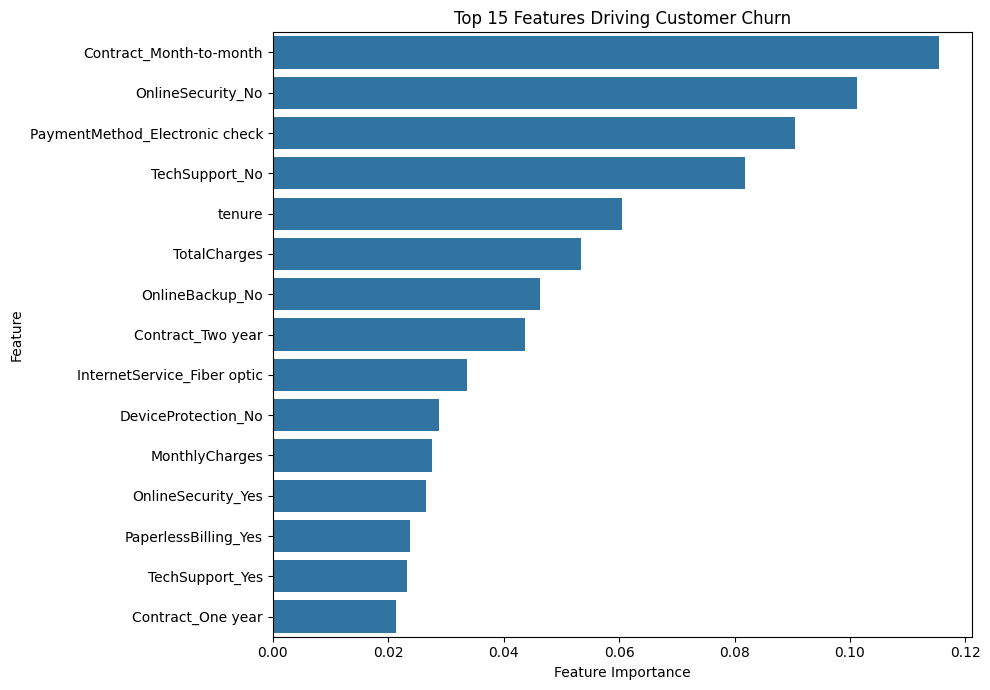

In [49]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features Driving Customer Churn")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [50]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    best_rf,
    X_test_processed,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [51]:
permutation_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": perm_importance.importances_mean,
    "Std": perm_importance.importances_std
})

permutation_df = permutation_df.sort_values(
    by="Importance",
    ascending=False
)

permutation_df.head(15)

,Feature,Importance,Std
36,Contract_Month-to-month,0.021240,0.005738
1,tenure,0.012898,0.002914
38,Contract_Two year,0.008844,0.001949
18,OnlineSecurity_No,0.008174,0.002509
3,TotalCharges,0.008163,0.002137
27,TechSupport_No,0.007289,0.003553
16,InternetService_Fiber optic,0.007069,0.002674
43,PaymentMethod_Electronic check,0.004547,0.002523
40,PaperlessBilling_Yes,0.003106,0.001357
39,PaperlessBilling_No,0.002446,0.001259


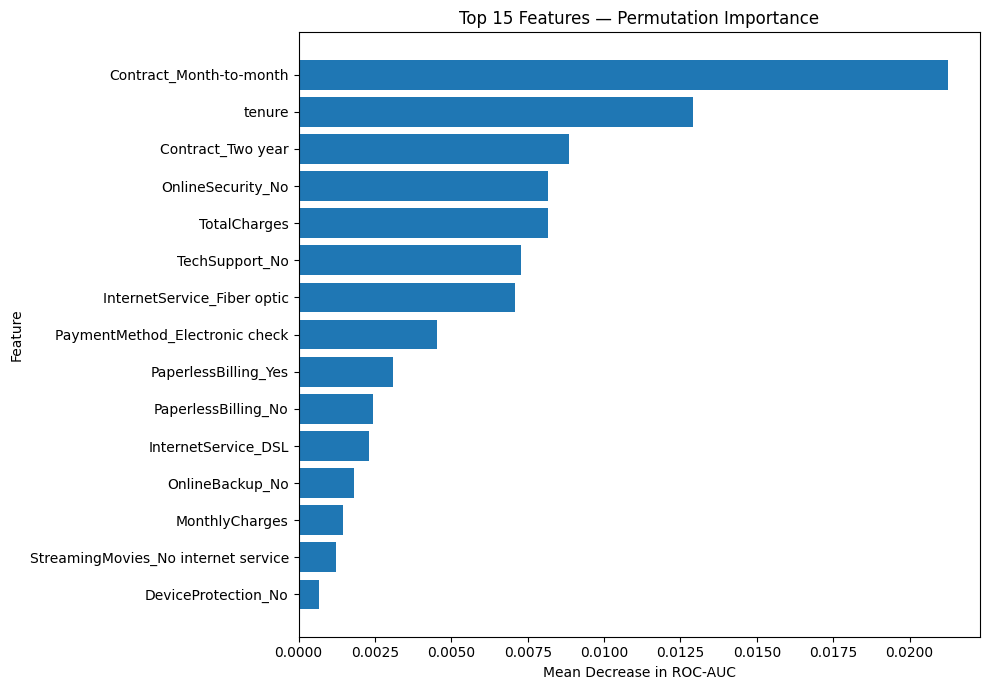

In [52]:
top_perm = permutation_df.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_perm["Feature"],
    top_perm["Importance"]
)

plt.title("Top 15 Features — Permutation Importance")
plt.xlabel("Mean Decrease in ROC-AUC")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [53]:
comparison_df = pd.merge(
    feature_importance_df,
    permutation_df,
    on="Feature",
    suffixes=("_RF", "_Permutation")
)

comparison_df = comparison_df.sort_values(
    by="Importance_Permutation",
    ascending=False
)

comparison_df.head(15)

,Feature,Importance_RF,Importance_Permutation,Std
0,Contract_Month-to-month,0.115412,0.021240,0.005738
4,tenure,0.060554,0.012898,0.002914
7,Contract_Two year,0.043688,0.008844,0.001949
1,OnlineSecurity_No,0.101175,0.008174,0.002509
5,TotalCharges,0.053359,0.008163,0.002137
3,TechSupport_No,0.081863,0.007289,0.003553
8,InternetService_Fiber optic,0.033705,0.007069,0.002674
2,PaymentMethod_Electronic check,0.090523,0.004547,0.002523
12,PaperlessBilling_Yes,0.023736,0.003106,0.001357
16,PaperlessBilling_No,0.017496,0.002446,0.001259


In [54]:
permutation_df.head(15)

,Feature,Importance,Std
36,Contract_Month-to-month,0.021240,0.005738
1,tenure,0.012898,0.002914
38,Contract_Two year,0.008844,0.001949
18,OnlineSecurity_No,0.008174,0.002509
3,TotalCharges,0.008163,0.002137
27,TechSupport_No,0.007289,0.003553
16,InternetService_Fiber optic,0.007069,0.002674
43,PaymentMethod_Electronic check,0.004547,0.002523
40,PaperlessBilling_Yes,0.003106,0.001357
39,PaperlessBilling_No,0.002446,0.001259


In [55]:
from sklearn.metrics import confusion_matrix

cm_final = confusion_matrix(
    y_test,
    y_pred_tuned
)

print(cm_final)

[[866 167]
 [146 228]]


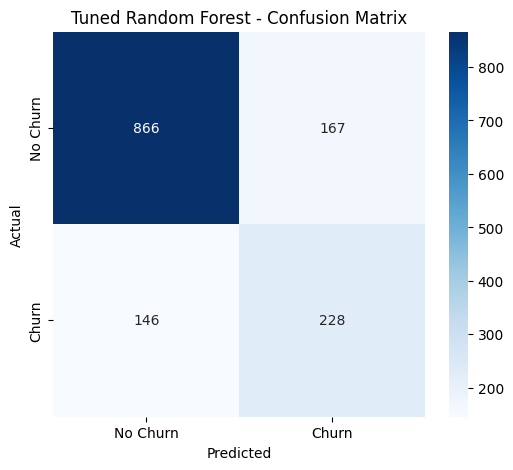

In [56]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Tuned Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

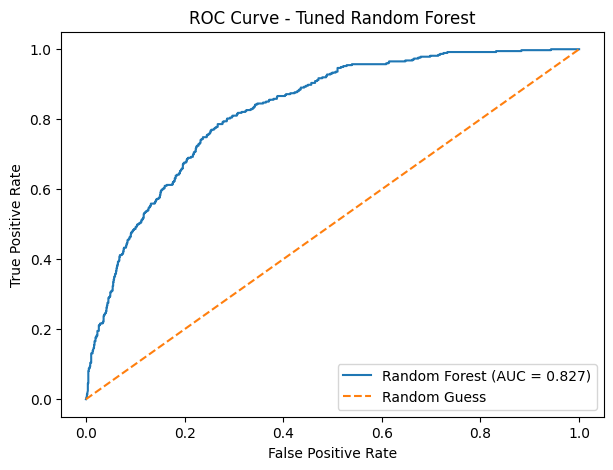

In [57]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_tuned
)

auc_score = roc_auc_score(
    y_test,
    y_prob_tuned
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")

plt.legend()
plt.show()

In [58]:
model_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        0.7186,
        0.7811,
        0.7775
    ],
    "Precision": [
        0.4736,
        0.6071,
        0.5772
    ],
    "Recall": [
        0.5267,
        0.5000,
        0.6096
    ],
    "F1 Score": [
        0.4987,
        0.5484,
        0.5930
    ],
    "ROC-AUC": [
        0.6582,
        0.8062,
        0.8273
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.7186,0.4736,0.5267,0.4987,0.6582
1,Random Forest,0.7811,0.6071,0.5000,0.5484,0.8062
2,Tuned Random Forest,0.7775,0.5772,0.6096,0.5930,0.8273


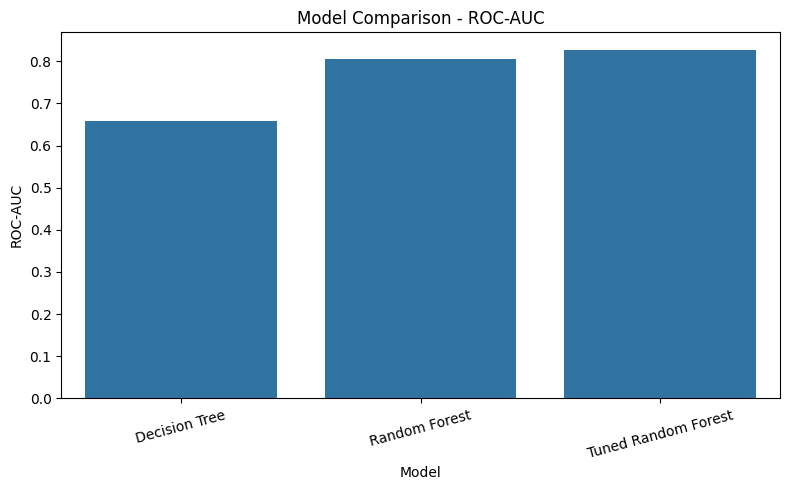

In [59]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="ROC-AUC"
)

plt.title("Model Comparison - ROC-AUC")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

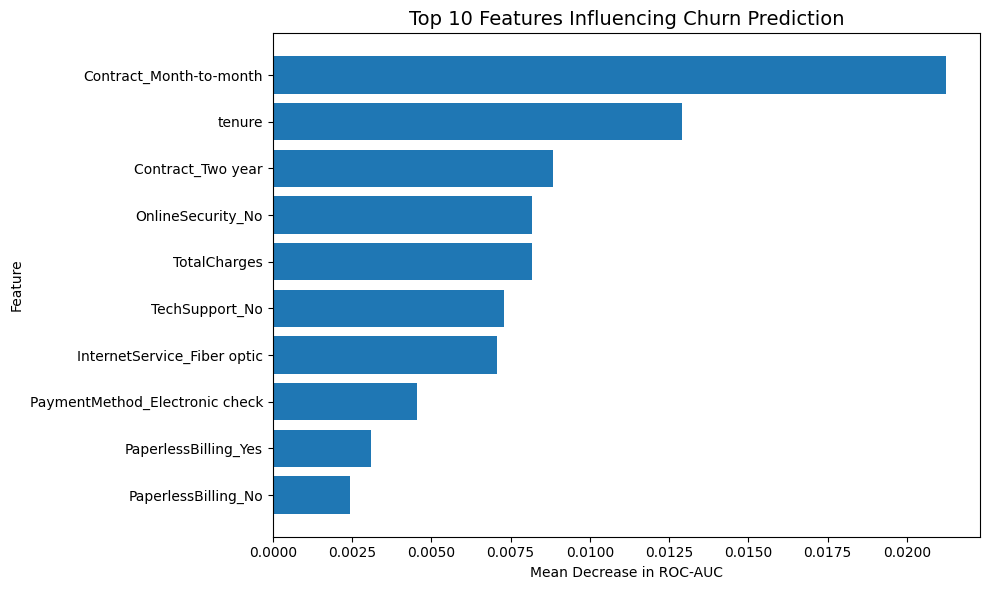

In [60]:
top_perm = permutation_df.head(10).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_perm["Feature"],
    top_perm["Importance"]
)

plt.title(
    "Top 10 Features Influencing Churn Prediction",
    fontsize=14
)

plt.xlabel(
    "Mean Decrease in ROC-AUC"
)

plt.ylabel("Feature")

plt.tight_layout()
plt.show()

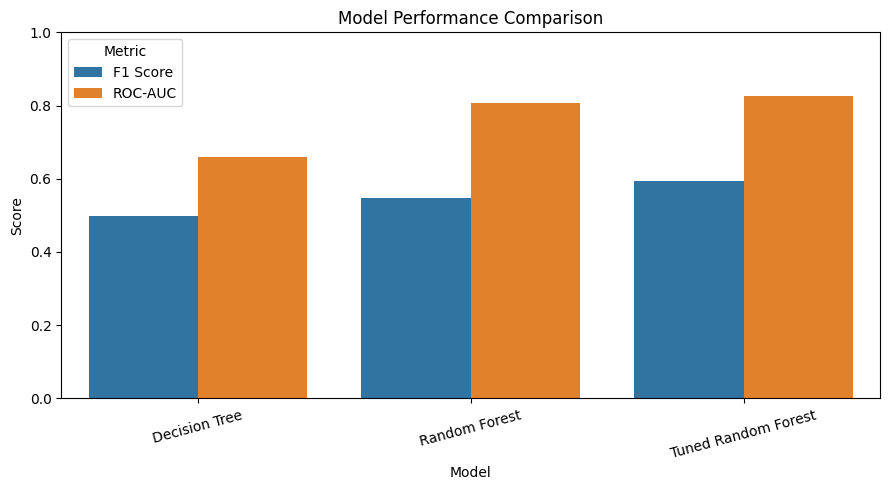

In [61]:
comparison_plot = model_comparison.melt(
    id_vars="Model",
    value_vars=["F1 Score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=comparison_plot,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")

plt.xticks(rotation=15)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()